In [12]:
import pandas as pd

df = pd.read_csv('./data/raw/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (233055, 11)

Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']

First few rows:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [10]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()


=== DATA TYPES ===
month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease            str
resale_price           float64
dtype: object

=== MISSING VALUES ===
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

=== BASIC STATISTICS ===


,floor_area_sqm,lease_commence_date,resale_price
count,233055.000000,233055.000000,2.330550e+05
mean,96.691907,1996.541748,5.307918e+05
std,24.016558,14.358283,1.900605e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.900000e+05
50%,93.000000,1997.000000,5.000000e+05
75%,112.000000,2012.000000,6.380000e+05
max,366.700000,2022.000000,1.728000e+06


In [11]:
print("=== FLAT TYPES ===")
print(df['flat_type'].value_counts())

print("\n=== TOWNS ===")
print(df['town'].value_counts())

print("\n=== STOREY RANGE (sample) ===")
print(df['storey_range'].value_counts().head(10))

print("\n=== FLAT MODELS ===")
print(df['flat_model'].value_counts())

=== FLAT TYPES ===
flat_type
4 ROOM              98932
5 ROOM              57012
3 ROOM              55513
EXECUTIVE           16589
2 ROOM               4837
1 ROOM                 86
MULTI-GENERATION       86
Name: count, dtype: int64

=== TOWNS ===
town
SENGKANG           18916
PUNGGOL            16881
WOODLANDS          16583
TAMPINES           16029
YISHUN             15822
JURONG WEST        15342
BEDOK              12109
HOUGANG            11764
CHOA CHU KANG      10482
BUKIT BATOK         9855
ANG MO KIO          9469
BUKIT MERAH         8897
BUKIT PANJANG       8317
TOA PAYOH           7637
KALLANG/WHAMPOA     7104
SEMBAWANG           7097
PASIR RIS           6719
QUEENSTOWN          6353
GEYLANG             5796
CLEMENTI            5181
JURONG EAST         4743
SERANGOON           4095
BISHAN              4063
CENTRAL AREA        1815
MARINE PARADE       1419
BUKIT TIMAH          567
Name: count, dtype: int64

=== STOREY RANGE (sample) ===
storey_range
04 TO 06    53444
07 TO

In [13]:
print("=== RESALE PRICE BY FLAT TYPE ===")
print(df.groupby('flat_type')['resale_price'].median().sort_values(ascending=False))

print("\n=== RESALE PRICE BY TOWN (top 10 most expensive) ===")
print(df.groupby('town')['resale_price'].median().sort_values(ascending=False).head(10))

print("\n=== DATE RANGE ===")
print("Earliest:", df['month'].min())
print("Latest:", df['month'].max())

=== RESALE PRICE BY FLAT TYPE ===
flat_type
MULTI-GENERATION    843500.0
EXECUTIVE           720000.0
5 ROOM              608888.0
4 ROOM              508000.0
3 ROOM              360000.0
2 ROOM              310000.0
1 ROOM              207500.0
Name: resale_price, dtype: float64

=== RESALE PRICE BY TOWN (top 10 most expensive) ===
town
BUKIT TIMAH        775000.0
BISHAN             690888.0
QUEENSTOWN         668000.0
BUKIT MERAH        656000.0
PASIR RIS          575000.0
CENTRAL AREA       570000.0
KALLANG/WHAMPOA    570000.0
TAMPINES           547000.0
SERANGOON          530000.0
PUNGGOL            530000.0
Name: resale_price, dtype: float64

=== DATE RANGE ===
Earliest: 2017-01
Latest: 2026-06


Matplotlib is building the font cache; this may take a moment.


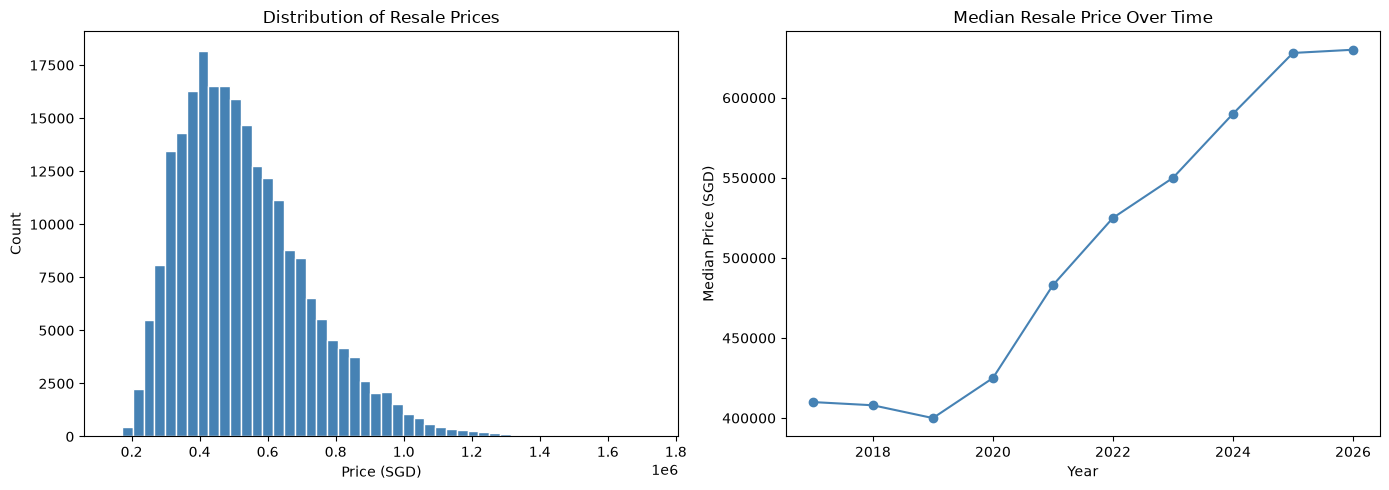

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df['resale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Resale Prices')
axes[0].set_xlabel('Price (SGD)')
axes[0].set_ylabel('Count')

# Price over time
df['year'] = df['month'].str[:4].astype(int)
yearly_median = df.groupby('year')['resale_price'].median()
axes[1].plot(yearly_median.index, yearly_median.values, marker='o', color='steelblue')
axes[1].set_title('Median Resale Price Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Price (SGD)')

plt.tight_layout()
plt.show()